In [1]:
# ==============================================================
# Celda 1 - Imports y configuracion
# Proyecto Integrador Fase 2 - Machine Learning
# Universidad Catolica Boliviana - Grupo 7 - Gestion 2026-I
# ==============================================================

import warnings
warnings.filterwarnings('ignore')

import json
import gzip
import random
import re
import string
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, accuracy_score,
    silhouette_score, davies_bouldin_score
)
import lightgbm as lgb
from flaml import AutoML

# Rutas relativas
BASE        = Path('..')
DATA_DIR    = BASE / 'data'
MODELS_DIR  = BASE / 'models'
REPORTS_DIR = BASE / 'reports' / 'figuras'
MLRUNS_DIR  = BASE / 'mlruns'

for _d in [DATA_DIR, MODELS_DIR, REPORTS_DIR, MLRUNS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# Semilla global
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

# NLTK
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
STOPWORDS_EN = set(stopwords.words('english'))

# MLflow
mlflow.set_tracking_uri(MLRUNS_DIR.resolve().as_uri())
mlflow.set_experiment('Fase2_ML_Grupo7')

print('Configuracion lista.')
print(f'  BASE       : {BASE.resolve()}')
print(f'  DATA_DIR   : {DATA_DIR.resolve()}')
print(f'  MODELS_DIR : {MODELS_DIR.resolve()}')

Configuracion lista.
  BASE       : C:\Users\ASUS\Desktop\PROYECTOS\FASE 2 ML\MiniRAG-ML-Home_and_Kitchen
  DATA_DIR   : C:\Users\ASUS\Desktop\PROYECTOS\FASE 2 ML\MiniRAG-ML-Home_and_Kitchen\data
  MODELS_DIR : C:\Users\ASUS\Desktop\PROYECTOS\FASE 2 ML\MiniRAG-ML-Home_and_Kitchen\models


---
## Seccion 1 — Carga del dataset

Se utiliza el dataset **Amazon Reviews 2023** (categoria *Home and Kitchen*).
El archivo comprimido `Home_and_Kitchen.jsonl.gz` (~7 GB) debe estar en `data/`.

**Estrategia de submuestreo:** se leen las reseñas linea a linea y se reservan aleatoriamente
20 000 registros por calificacion (1 a 5 estrellas), obteniendo **100 000 reseñas balanceadas**.
El resultado se guarda en `data/subset_raw.parquet` para reutilizacion.

Campos extraidos: `rating`, `text`, `verified_purchase`, `helpful_vote`.

In [2]:
# ==============================================================
# Celda 3 - Carga con submuestreo estratificado
# ==============================================================

RAW_PARQUET  = DATA_DIR / 'subset_raw.parquet'
GZ_FILE      = DATA_DIR / 'Home_and_Kitchen.jsonl.gz'
N_PER_RATING = 20_000

if RAW_PARQUET.exists():
    print('Cargando subset_raw.parquet (cache)...')
    df_raw = pd.read_parquet(RAW_PARQUET)
else:
    if not GZ_FILE.exists():
        raise FileNotFoundError(
            f'Archivo no encontrado: {GZ_FILE}\n'
            'Descargue Home_and_Kitchen.jsonl.gz y coloquelo en data/'
        )
    print('Leyendo archivo comprimido (puede tardar varios minutos)...')

    buckets = {r: [] for r in range(1, 6)}
    completed = set()

    with gzip.open(GZ_FILE, 'rt', encoding='utf-8') as fh:
        for line in fh:
            if len(completed) == 5:
                break
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue

            rating = int(float(rec.get('rating', 0)))
            if rating not in range(1, 6):
                continue
            if rating in completed:
                continue

            text = str(rec.get('text', '')).strip()
            if len(text) < 10:
                continue

            buckets[rating].append({
                'rating'           : rating,
                'text'             : text,
                'verified_purchase': bool(rec.get('verified_purchase', False)),
                'helpful_vote'     : int(rec.get('helpful_vote', 0)),
            })

            if len(buckets[rating]) >= N_PER_RATING:
                completed.add(rating)

    records = []
    for r in range(1, 6):
        sample = buckets[r][:N_PER_RATING]
        records.extend(sample)

    df_raw = pd.DataFrame(records)
    df_raw.to_parquet(RAW_PARQUET, index=False)
    print(f'subset_raw.parquet guardado ({len(df_raw):,} registros)')

print(f'Shape: {df_raw.shape}')
print(f'Distribucion ratings:\n{df_raw["rating"].value_counts().sort_index()}')
df_raw.head(3)

Cargando subset_raw.parquet (cache)...
Shape: (100000, 4)
Distribucion ratings:
rating
1    20000
2    20000
3    20000
4    20000
5    20000
Name: count, dtype: int64


,rating,text,verified_purchase,helpful_vote
0,1,Livid. Once again received an obviously used ...,True,1
1,1,Dryer/Fire risk! Previously I wrote a lovely...,True,115
2,1,I bought this after reading a TON of reviews a...,True,4


---
## Seccion 2 — Analisis Exploratorio de Datos (EDA)

Se analiza la distribucion de calificaciones, la longitud de las reseñas,
la calidad textual, las palabras mas frecuentes y el estado de compra verificada.
El objetivo es identificar patrones y posibles problemas antes del preprocesamiento.

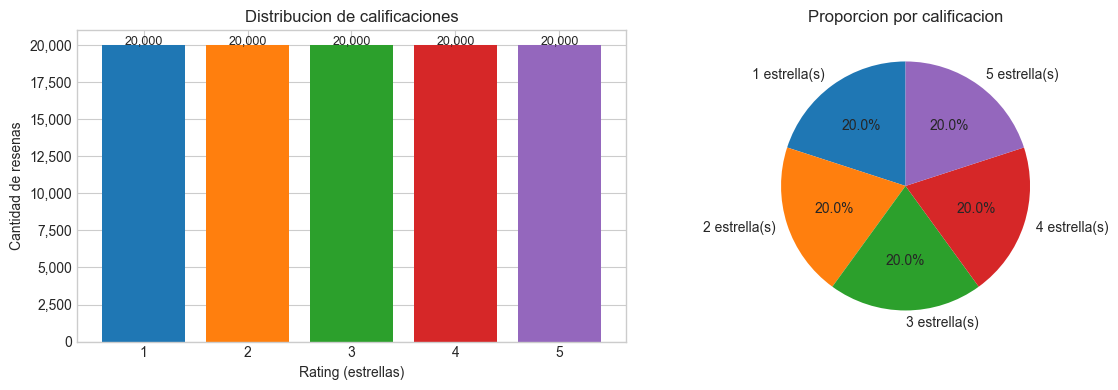

In [3]:
# ==============================================================
# Celda 5 - EDA: distribucion de calificaciones
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_raw['rating'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=sns.color_palette('tab10', 5))
axes[0].set_title('Distribucion de calificaciones')
axes[0].set_xlabel('Rating (estrellas)')
axes[0].set_ylabel('Cantidad de resenas')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(counts.values):
    axes[0].text(i + 1, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    counts.values,
    labels=[f'{r} estrella(s)' for r in counts.index],
    autopct='%1.1f%%',
    colors=sns.color_palette('tab10', 5),
    startangle=90
)
axes[1].set_title('Proporcion por calificacion')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_distribucion_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

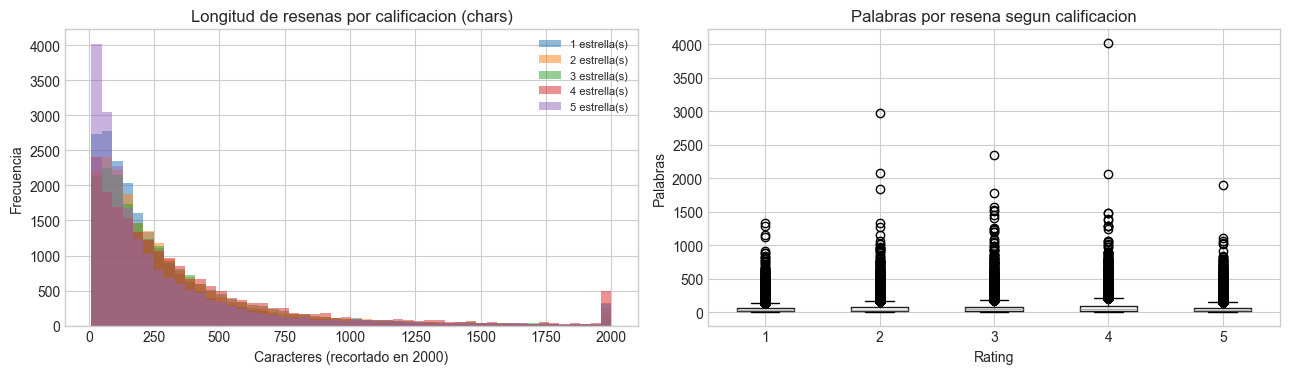

Estadisticas de longitud (caracteres):
count    100000.0
mean        339.0
std         473.6
min          10.0
25%          86.0
50%         194.0
75%         403.0
max       22296.0
Name: text_len, dtype: float64

Resenas con texto vacio o muy corto (<10 chars): 0


In [4]:
# ==============================================================
# Celda 6 - EDA: longitud de resenas
# ==============================================================

df_raw['text_len'] = df_raw['text'].str.len()
df_raw['word_count'] = df_raw['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for rating in range(1, 6):
    subset = df_raw[df_raw['rating'] == rating]['text_len']
    axes[0].hist(subset.clip(upper=2000), bins=50, alpha=0.5, label=f'{rating} estrella(s)')
axes[0].set_title('Longitud de resenas por calificacion (chars)')
axes[0].set_xlabel('Caracteres (recortado en 2000)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=8)

df_raw.boxplot(column='word_count', by='rating', ax=axes[1])
axes[1].set_title('Palabras por resena segun calificacion')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Palabras')
plt.suptitle('')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_longitud_resenas.png', dpi=150, bbox_inches='tight')
plt.show()

print('Estadisticas de longitud (caracteres):')
print(df_raw['text_len'].describe().round(1))
print(f'\nResenas con texto vacio o muy corto (<10 chars): {(df_raw["text_len"] < 10).sum()}')

=== Calidad del dataset ===
Total registros : 100,000
Duplicados      : 1,371

Nulos por columna:
rating               0
text                 0
verified_purchase    0
helpful_vote         0
text_len             0
word_count           0
dtype: int64

Textos con menos de 20 caracteres: 3,264
Textos con mas de 5000 caracteres: 67


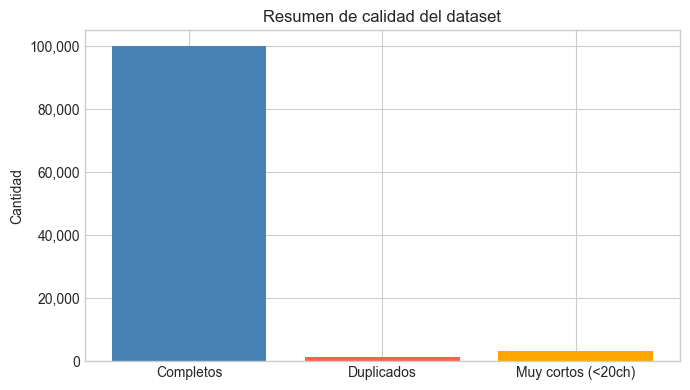

In [5]:
# ==============================================================
# Celda 7 - EDA: calidad del dataset
# ==============================================================

print('=== Calidad del dataset ===')
print(f'Total registros : {len(df_raw):,}')
print(f'Duplicados      : {df_raw.duplicated(subset="text").sum():,}')
print(f'\nNulos por columna:')
print(df_raw.isnull().sum())

print(f'\nTextos con menos de 20 caracteres: {(df_raw["text_len"] < 20).sum():,}')
print(f'Textos con mas de 5000 caracteres: {(df_raw["text_len"] > 5000).sum():,}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    ['Completos', 'Duplicados', 'Muy cortos (<20ch)'],
    [
        len(df_raw),
        df_raw.duplicated(subset='text').sum(),
        (df_raw['text_len'] < 20).sum()
    ],
    color=['steelblue', 'tomato', 'orange']
)
ax.set_title('Resumen de calidad del dataset')
ax.set_ylabel('Cantidad')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_calidad.png', dpi=150, bbox_inches='tight')
plt.show()

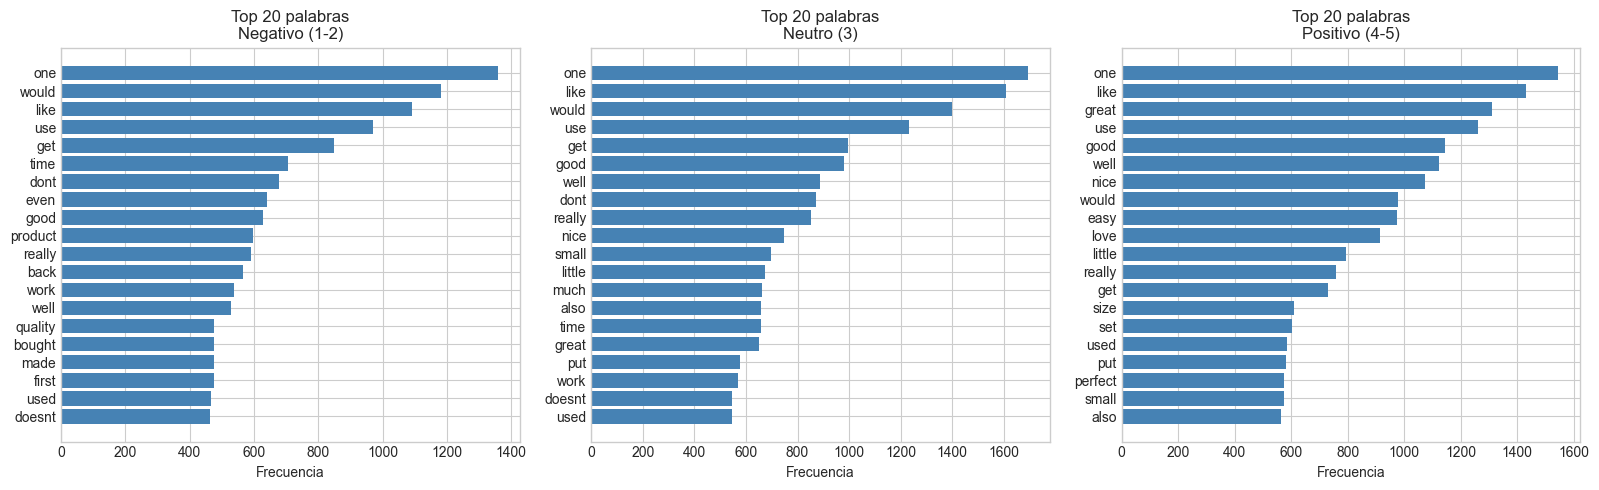

In [6]:
# ==============================================================
# Celda 8 - EDA: palabras mas frecuentes
# ==============================================================

def tokenize_simple(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS_EN and len(t) > 2]


# Top palabras por sentimiento (muestra de 5000 resenas por grupo)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

groups = [
    ('Negativo (1-2)', df_raw[df_raw['rating'] <= 2]),
    ('Neutro (3)',     df_raw[df_raw['rating'] == 3]),
    ('Positivo (4-5)', df_raw[df_raw['rating'] >= 4]),
]

for ax, (title, grp) in zip(axes, groups):
    sample_texts = grp['text'].sample(min(5000, len(grp)), random_state=SEED)
    all_tokens = []
    for t in sample_texts:
        all_tokens.extend(tokenize_simple(t))
    top20 = Counter(all_tokens).most_common(20)
    words, freqs = zip(*top20)
    ax.barh(list(reversed(words)), list(reversed(freqs)), color='steelblue')
    ax.set_title(f'Top 20 palabras\n{title}')
    ax.set_xlabel('Frecuencia')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_palabras_frecuentes.png', dpi=150, bbox_inches='tight')
plt.show()

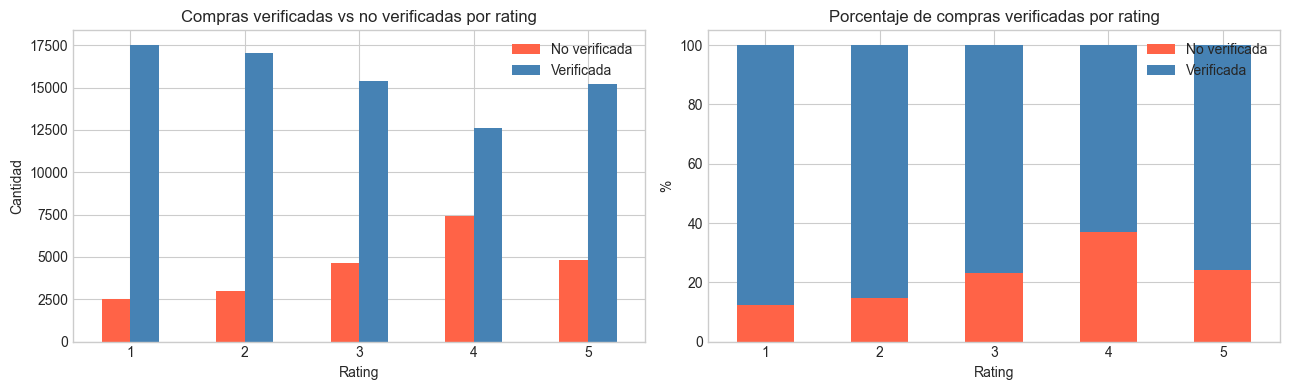

Tasa global de compras verificadas: 77.7%


In [7]:
# ==============================================================
# Celda 9 - EDA: compras verificadas
# ==============================================================

verified_counts = df_raw.groupby(['rating', 'verified_purchase']).size().unstack(fill_value=0)
verified_pct    = verified_counts.div(verified_counts.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

verified_counts.plot(kind='bar', ax=axes[0], color=['tomato', 'steelblue'])
axes[0].set_title('Compras verificadas vs no verificadas por rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['No verificada', 'Verificada'])

verified_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['tomato', 'steelblue'])
axes[1].set_title('Porcentaje de compras verificadas por rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['No verificada', 'Verificada'])

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_compras_verificadas.png', dpi=150, bbox_inches='tight')
plt.show()

print('Tasa global de compras verificadas: '
      f"{df_raw['verified_purchase'].mean()*100:.1f}%")

---
## Seccion 3 — Preparacion de Datos

Pasos:
1. **Etiquetado:** se crea la variable objetivo `label` (0=Negativo, 1=Neutro, 2=Positivo).
2. **Limpieza textual:** minusculas, eliminacion de HTML, puntuacion, digitos, stopwords y tokens cortos.
3. **Particion 70/15/15** estratificada por `label`, aplicada **antes** de ajustar TF-IDF.
4. **TF-IDF:** `fit()` solo sobre `X_train`, luego `transform()` sobre los tres splits.
   - Version estandar: 50 000 features (para LR, RF, LightGBM).
   - Version compacta: 10 000 features (para FLAML, evitar saturacion de RAM).

Distribucion de etiquetas:
label
Negativo    40000
Neutro      20000
Positivo    40000
Name: count, dtype: int64


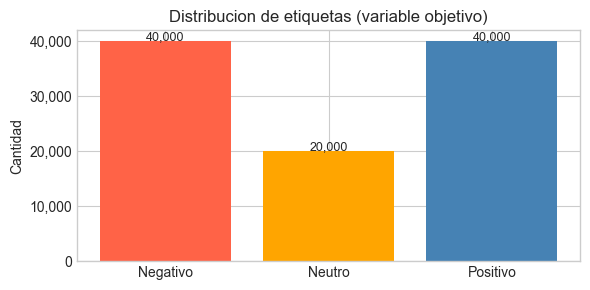

In [8]:
# ==============================================================
# Celda 11 - Etiquetas
# ==============================================================

def assign_label(rating):
    r = int(float(rating))
    if r <= 2:
        return 0   # Negativo
    elif r == 3:
        return 1   # Neutro
    else:
        return 2   # Positivo


df_raw['label'] = df_raw['rating'].apply(assign_label)

label_map = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}

print('Distribucion de etiquetas:')
print(df_raw['label'].value_counts().sort_index().rename(label_map))

fig, ax = plt.subplots(figsize=(6, 3))
vc = df_raw['label'].value_counts().sort_index()
ax.bar([label_map[k] for k in vc.index], vc.values,
       color=['tomato', 'orange', 'steelblue'])
ax.set_title('Distribucion de etiquetas (variable objetivo)')
ax.set_ylabel('Cantidad')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(vc.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'prep_etiquetas.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ==============================================================
# Celda 12 - Limpieza textual
# ==============================================================

RE_HTML    = re.compile(r'<[^>]+>')
RE_URL     = re.compile(r'http\S+')
RE_NONALPH = re.compile(r'[^a-z\s]')
RE_SPACES  = re.compile(r'\s+')


def clean_text(text):
    text = str(text).lower()
    text = RE_HTML.sub(' ', text)
    text = RE_URL.sub(' ', text)
    text = RE_NONALPH.sub(' ', text)
    tokens = RE_SPACES.sub(' ', text).strip().split()
    tokens = [t for t in tokens if t not in STOPWORDS_EN and len(t) > 2]
    return ' '.join(tokens)


print('Aplicando limpieza textual...')
df_raw['text_clean'] = df_raw['text'].apply(clean_text)

df_raw['clean_len'] = df_raw['text_clean'].str.len()
print(f'Longitud media antes de limpieza : {df_raw["text_len"].mean():.0f} chars')
print(f'Longitud media despues de limpieza: {df_raw["clean_len"].mean():.0f} chars')

print('\nEjemplo de limpieza:')
idx = 0
print(f'  Original : {df_raw["text"].iloc[idx][:200]}')
print(f'  Limpio   : {df_raw["text_clean"].iloc[idx][:200]}')

Aplicando limpieza textual...
Longitud media antes de limpieza : 339 chars
Longitud media despues de limpieza: 198 chars

Ejemplo de limpieza:
  Original : Livid.  Once again received an obviously used item that has food on it & scratches. I purchased this new!!  Pics not loading rn. Will add them later. Disgusted.
  Limpio   : livid received obviously used item food scratches purchased new pics loading add later disgusted


In [10]:
# ==============================================================
# Celda 13 - Particion 70/15/15 estratificada
# ==============================================================

X_all = df_raw['text_clean'].values
y_all = df_raw['label'].values

# Primera particion: train (70%) vs temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.30,
    stratify=y_all,
    random_state=SEED
)

# Segunda particion: val (15%) vs test (15%) del 30% restante
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print('Particion completada:')
print(f'  Train : {len(X_train):,} ({len(X_train)/len(X_all)*100:.1f}%)')
print(f'  Val   : {len(X_val):,} ({len(X_val)/len(X_all)*100:.1f}%)')
print(f'  Test  : {len(X_test):,} ({len(X_test)/len(X_all)*100:.1f}%)')

print('\nDistribucion de clases en train:')
for lbl, name in label_map.items():
    n = (y_train == lbl).sum()
    print(f'  {name}: {n:,} ({n/len(y_train)*100:.1f}%)')

# Guardar split en parquet
SPLIT_PARQUET = DATA_DIR / 'subset_split.parquet'
df_split = pd.DataFrame({
    'text_clean': np.concatenate([X_train, X_val, X_test]),
    'label'     : np.concatenate([y_train, y_val, y_test]),
    'split'     : ['train'] * len(X_train) + ['val'] * len(X_val) + ['test'] * len(X_test)
})
df_split.to_parquet(SPLIT_PARQUET, index=False)
print(f'\nsubset_split.parquet guardado.')

Particion completada:
  Train : 70,000 (70.0%)
  Val   : 15,000 (15.0%)
  Test  : 15,000 (15.0%)

Distribucion de clases en train:
  Negativo: 28,000 (40.0%)
  Neutro: 14,000 (20.0%)
  Positivo: 28,000 (40.0%)

subset_split.parquet guardado.


In [11]:
# ==============================================================
# Celda 14 - TF-IDF (fit solo en X_train)
# ==============================================================

# --- TF-IDF estandar (50k features) para LR, RF, LightGBM ---
print('Ajustando TF-IDF estandar (max_features=50000)...')
tfidf = TfidfVectorizer(
    max_features=50_000,
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=3
)
tfidf.fit(X_train)

X_tr  = tfidf.transform(X_train)
X_vl  = tfidf.transform(X_val)
X_te  = tfidf.transform(X_test)

print(f'Shape TF-IDF train : {X_tr.shape}')
print(f'Shape TF-IDF val   : {X_vl.shape}')
print(f'Shape TF-IDF test  : {X_te.shape}')

# --- TF-IDF compacto (10k features) para FLAML ---
print('\nAjustando TF-IDF compacto (max_features=10000) para FLAML...')
tfidf_flaml = TfidfVectorizer(
    max_features=10_000,
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=3
)
tfidf_flaml.fit(X_train)

X_tr_f  = tfidf_flaml.transform(X_train)
X_vl_f  = tfidf_flaml.transform(X_val)
X_te_f  = tfidf_flaml.transform(X_test)

print(f'Shape TF-IDF FLAML train: {X_tr_f.shape}')
print('Preparacion de datos completada.')

# Representacion LSA para FLAML (mismo SVD que se usa en clustering)
from sklearn.decomposition import TruncatedSVD
svd_flaml = TruncatedSVD(n_components=100, random_state=SEED)
X_tr_svd_fl = svd_flaml.fit_transform(X_tr)
X_vl_svd_fl = svd_flaml.transform(X_vl)
X_te_svd_fl = svd_flaml.transform(X_te)
print(f'LSA para FLAML: {X_tr_svd_fl.shape}')

Ajustando TF-IDF estandar (max_features=50000)...
Shape TF-IDF train : (70000, 50000)
Shape TF-IDF val   : (15000, 50000)
Shape TF-IDF test  : (15000, 50000)

Ajustando TF-IDF compacto (max_features=10000) para FLAML...
Shape TF-IDF FLAML train: (70000, 10000)
Preparacion de datos completada.
LSA para FLAML: (70000, 100)


---
## Seccion 4 — Modelado

Se entrenan cuatro modelos de clasificacion multiclase (3 clases: Negativo, Neutro, Positivo):

| Modelo | Descripcion |
|--------|-------------|
| Logistic Regression | Baseline lineal, rapido y interpretable |
| Random Forest | Ensemble de arboles, captura no linealidades |
| LightGBM | Gradient boosting eficiente, alta capacidad |
| FLAML AutoML | Busqueda automatica del mejor modelo/hiperparametros |

Cada modelo se registra en **MLflow** con sus metricas sobre el conjunto de validacion.
La evaluacion final (test set) se realiza en la Seccion 5.

In [12]:
# ==============================================================
# Celda 16 - Funcion evaluar()
# ==============================================================

CLASS_NAMES = ['Negativo', 'Neutro', 'Positivo']


def evaluar(modelo, X_tr, y_tr, X_eval, y_eval, nombre, log_mlflow=True):
    """
    Evalua un modelo clasificador y retorna un dict con metricas.
    Si log_mlflow=True, registra las metricas en el experimento activo.
    """
    y_pred = modelo.predict(X_eval)

    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_eval)
    else:
        y_proba = None

    acc     = accuracy_score(y_eval, y_pred)
    f1      = f1_score(y_eval, y_pred, average='macro')
    roc_auc = (
        roc_auc_score(y_eval, y_proba, multi_class='ovr', average='macro')
        if y_proba is not None else float('nan')
    )

    metricas = {'modelo': nombre, 'accuracy': acc, 'f1_macro': f1, 'roc_auc': roc_auc}

    if log_mlflow:
        with mlflow.start_run(run_name=nombre, nested=True):
            mlflow.log_metrics({'accuracy': acc, 'f1_macro': f1, 'roc_auc': roc_auc})

    print(f'\n--- {nombre} ---')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1-macro : {f1:.4f}')
    print(f'  ROC-AUC  : {roc_auc:.4f}')
    print(classification_report(y_eval, y_pred, target_names=CLASS_NAMES))

    return metricas


resultados = []
print('Funcion evaluar() lista.')

Funcion evaluar() lista.


In [13]:
# ==============================================================
# Celda 17 - Modelo 1: Logistic Regression (baseline)
# ==============================================================

print('Entrenando Logistic Regression...')
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='saga',
    n_jobs=-1,
    random_state=SEED
)
lr_model.fit(X_tr, y_train)

metricas_lr = evaluar(lr_model, X_tr, y_train, X_vl, y_val, 'Logistic Regression')
resultados.append(metricas_lr)

joblib.dump(lr_model, MODELS_DIR / 'lr_model.pkl')
print('lr_model.pkl guardado.')

Entrenando Logistic Regression...

--- Logistic Regression ---
  Accuracy : 0.7185
  F1-macro : 0.6334
  ROC-AUC  : 0.8514
              precision    recall  f1-score   support

    Negativo       0.73      0.83      0.77      6000
      Neutro       0.48      0.24      0.32      3000
    Positivo       0.76      0.85      0.80      6000

    accuracy                           0.72     15000
   macro avg       0.66      0.64      0.63     15000
weighted avg       0.69      0.72      0.70     15000

lr_model.pkl guardado.


In [14]:
# ==============================================================
# Celda 18 - Modelo 2: Random Forest
# ==============================================================

print('Entrenando Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=SEED
)
rf_model.fit(X_tr, y_train)

metricas_rf = evaluar(rf_model, X_tr, y_train, X_vl, y_val, 'Random Forest')
resultados.append(metricas_rf)

joblib.dump(rf_model, MODELS_DIR / 'rf_model.pkl')
print('rf_model.pkl guardado.')

Entrenando Random Forest...

--- Random Forest ---
  Accuracy : 0.6895
  F1-macro : 0.5216
  ROC-AUC  : 0.8299
              precision    recall  f1-score   support

    Negativo       0.69      0.85      0.76      6000
      Neutro       0.53      0.02      0.03      3000
    Positivo       0.69      0.87      0.77      6000

    accuracy                           0.69     15000
   macro avg       0.64      0.58      0.52     15000
weighted avg       0.66      0.69      0.62     15000

rf_model.pkl guardado.


In [15]:
# ==============================================================
# Celda 19 - Modelo 3: LightGBM
# ==============================================================

print('Entrenando LightGBM...')
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=SEED,
    verbose=-1
)
lgbm_model.fit(
    X_tr, y_train,
    eval_set=[(X_vl, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)

metricas_lgbm = evaluar(lgbm_model, X_tr, y_train, X_vl, y_val, 'LightGBM')
resultados.append(metricas_lgbm)

joblib.dump(lgbm_model, MODELS_DIR / 'lgbm_model.pkl')
print('lgbm_model.pkl guardado.')

Entrenando LightGBM...

--- LightGBM ---
  Accuracy : 0.7124
  F1-macro : 0.6317
  ROC-AUC  : 0.8452
              precision    recall  f1-score   support

    Negativo       0.73      0.81      0.77      6000
      Neutro       0.46      0.26      0.33      3000
    Positivo       0.76      0.84      0.80      6000

    accuracy                           0.71     15000
   macro avg       0.65      0.64      0.63     15000
weighted avg       0.69      0.71      0.69     15000

lgbm_model.pkl guardado.


In [16]:
# ==============================================================
# Celda 20 - Modelo 4: FLAML AutoML
# FLAML AutoML sobre representacion LSA (100 dims del TF-IDF de 50k features)
# ==============================================================

print('Entrenando FLAML AutoML (tiempo limite: 120 segundos)...')
flaml_model = AutoML()
flaml_model.fit(
    X_tr_svd_fl, y_train,
    task='classification',
    time_budget=120,
    metric='macro_f1',
    seed=SEED,
    verbose=0
)

print(f'Mejor estimador FLAML : {flaml_model.best_estimator}')
print(f'Mejor config          : {flaml_model.best_config}')

metricas_flaml = evaluar(flaml_model, X_tr_svd_fl, y_train, X_vl_svd_fl, y_val, 'FLAML AutoML')
resultados.append(metricas_flaml)

joblib.dump(flaml_model, MODELS_DIR / 'flaml_automl.pkl')
print('flaml_automl.pkl guardado.')

Entrenando FLAML AutoML (tiempo limite: 120 segundos)...
Mejor estimador FLAML : lgbm
Mejor config          : {'n_estimators': 5305, 'num_leaves': 7, 'min_child_samples': 10, 'learning_rate': np.float64(0.32852813587113083), 'log_max_bin': 7, 'colsample_bytree': np.float64(0.9778726268416658), 'reg_alpha': np.float64(0.1545796946870627), 'reg_lambda': np.float64(0.24102974843418593)}

--- FLAML AutoML ---
  Accuracy : 0.6593
  F1-macro : 0.5730
  ROC-AUC  : 0.7951
              precision    recall  f1-score   support

    Negativo       0.68      0.76      0.72      6000
      Neutro       0.35      0.19      0.25      3000
    Positivo       0.71      0.79      0.75      6000

    accuracy                           0.66     15000
   macro avg       0.58      0.58      0.57     15000
weighted avg       0.63      0.66      0.64     15000

flaml_automl.pkl guardado.


---
## Seccion 5 — Comparacion de Modelos

Se comparan los cuatro modelos evaluados sobre el conjunto de **prueba (test set)**,
que no fue utilizado durante el entrenamiento ni la seleccion de hiperparametros.

Metricas de comparacion: **Accuracy**, **F1-macro** y **ROC-AUC OvR**.
Adicionalmente se presentan matrices de confusion y un analisis de errores tipicos.

In [17]:
# ==============================================================
# Celda 22 - Tabla comparativa (test set)
# ==============================================================

modelos_eval = [
    ('Logistic Regression', lr_model,    X_te,   y_test),
    ('Random Forest',       rf_model,    X_te,   y_test),
    ('LightGBM',            lgbm_model,  X_te,   y_test),
    ('FLAML AutoML',        flaml_model, X_te_svd_fl, y_test),
]

resultados_test = []
for nombre, modelo, X_ev, y_ev in modelos_eval:
    y_pred  = modelo.predict(X_ev)
    y_proba = modelo.predict_proba(X_ev) if hasattr(modelo, 'predict_proba') else None
    acc     = accuracy_score(y_ev, y_pred)
    f1      = f1_score(y_ev, y_pred, average='macro')
    roc_auc = (
        roc_auc_score(y_ev, y_proba, multi_class='ovr', average='macro')
        if y_proba is not None else float('nan')
    )
    resultados_test.append({
        'Modelo'   : nombre,
        'Accuracy' : round(acc, 4),
        'F1-macro' : round(f1, 4),
        'ROC-AUC'  : round(roc_auc, 4)
    })

df_resultados = pd.DataFrame(resultados_test).sort_values('F1-macro', ascending=False)
df_resultados = df_resultados.reset_index(drop=True)
print('Resultados en Test Set:')
display(df_resultados)

Resultados en Test Set:


,Modelo,Accuracy,F1-macro,ROC-AUC
0,Logistic Regression,0.7192,0.6307,0.8509
1,LightGBM,0.7089,0.6289,0.8456
2,FLAML AutoML,0.6581,0.5718,0.7987
3,Random Forest,0.6865,0.5199,0.8302


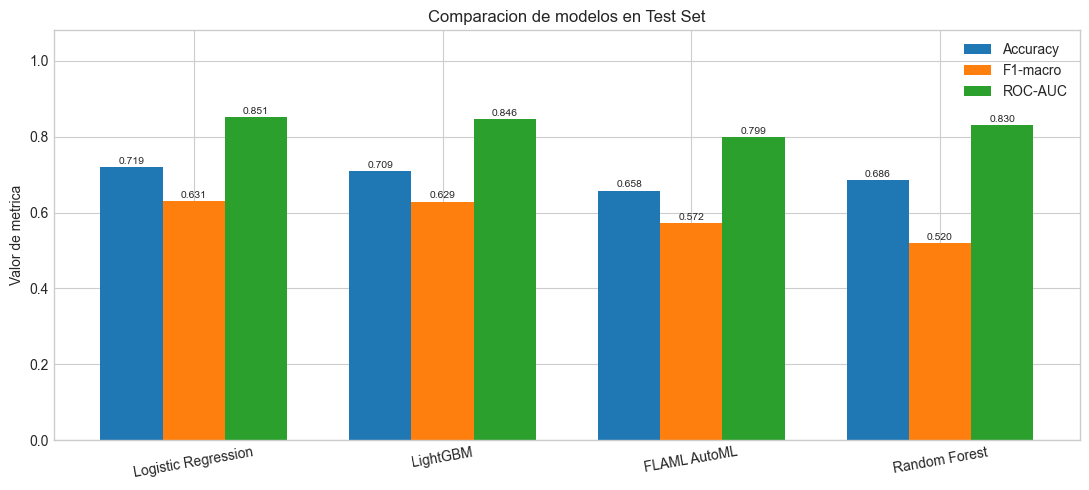

In [18]:
# ==============================================================
# Celda 23 - Grafico comparativo de metricas
# ==============================================================

metricas_cols = ['Accuracy', 'F1-macro', 'ROC-AUC']
x = np.arange(len(df_resultados))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, metrica in enumerate(metricas_cols):
    bars = ax.bar(
        x + (i - 1) * width,
        df_resultados[metrica],
        width,
        label=metrica
    )
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.003,
            f'{h:.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

ax.set_xticks(x)
ax.set_xticklabels(df_resultados['Modelo'], rotation=10)
ax.set_ylim(0, 1.08)
ax.set_title('Comparacion de modelos en Test Set')
ax.set_ylabel('Valor de metrica')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

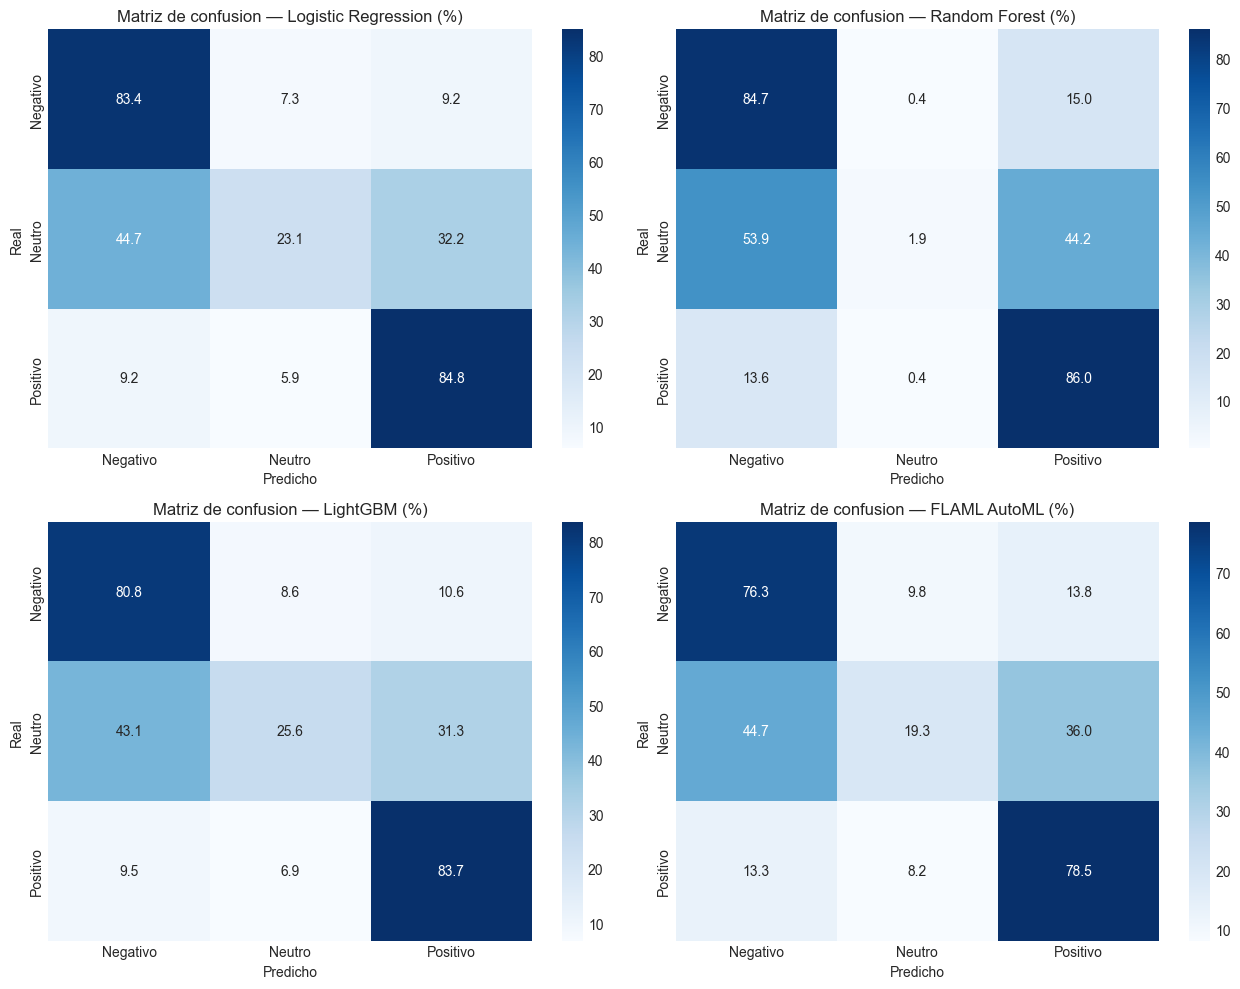

In [19]:
# ==============================================================
# Celda 24 - Matrices de confusion
# ==============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (nombre, modelo, X_ev, y_ev) in zip(axes, modelos_eval):
    y_pred = modelo.predict(X_ev)
    cm     = confusion_matrix(y_ev, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax
    )
    ax.set_title(f'Matriz de confusion — {nombre} (%)')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ==============================================================
# Celda 25 - Analisis de errores (mejor modelo)
# ==============================================================

mejor_nombre = df_resultados.iloc[0]['Modelo']
print(f'Mejor modelo segun F1-macro: {mejor_nombre}')

mejor_idx   = [n for n, _, _, _ in modelos_eval].index(mejor_nombre)
_, mejor_m, X_mejor, _ = modelos_eval[mejor_idx]
y_pred_mejor = mejor_m.predict(X_mejor)

# Resenas mal clasificadas
errores_mask = y_pred_mejor != y_test
print(f'Errores totales en test: {errores_mask.sum():,} / {len(y_test):,} ({errores_mask.mean()*100:.1f}%)')

# Ejemplos de errores tipicos
df_errores = pd.DataFrame({
    'texto'    : X_test[errores_mask],
    'real'     : [CLASS_NAMES[l] for l in y_test[errores_mask]],
    'predicho' : [CLASS_NAMES[l] for l in y_pred_mejor[errores_mask]]
})

print('\nEjemplos de clasificaciones incorrectas:')
for _, row in df_errores.sample(5, random_state=SEED).iterrows():
    print(f'  Real: {row["real"]:10s} | Pred: {row["predicho"]:10s} | Texto: {row["texto"][:100]}')

# Distribucion de errores por clase real
error_dist = pd.crosstab(
    [CLASS_NAMES[l] for l in y_test[errores_mask]],
    [CLASS_NAMES[l] for l in y_pred_mejor[errores_mask]],
    rownames=['Real'], colnames=['Predicho']
)
print('\nDistribucion de errores (Real vs Predicho):')
display(error_dist)

Mejor modelo segun F1-macro: Logistic Regression
Errores totales en test: 4,212 / 15,000 (28.1%)

Ejemplos de clasificaciones incorrectas:
  Real: Neutro     | Pred: Positivo   | Texto: assembled bed stong geometric modern look qulaityoverall aveerage mine arrived looking like losing e
  Real: Neutro     | Pred: Negativo   | Texto: performance food processor great however issues prevent giving higher star rating others pointed pus
  Real: Negativo   | Pred: Neutro     | Texto: sprayer really hard get mist olive oil spray like stream wanted lightly spray foods air frying falls
  Real: Positivo   | Pred: Negativo   | Texto: function tad flimsy easy assemble insides least work
  Real: Neutro     | Pred: Negativo   | Texto: spring staging book shelf appear real distance one get close lol

Distribucion de errores (Real vs Predicho):


Predicho,Negativo,Neutro,Positivo
Real,,,
Negativo,0,440,555
Neutro,1340,0,967
Positivo,554,356,0


---
## Seccion 6 — Clustering K-Means

Se aplica clustering no supervisado sobre la representacion latente de los textos:

1. **SVD/LSA** reduce la matriz TF-IDF a 100 dimensiones.
2. **Seleccion de K** mediante el metodo del codo (inercia) y el coeficiente de silueta.
3. **K-Means** con el K optimo seleccionado.
4. **Interpretacion:** terminos mas representativos por cluster.
5. **Visualizacion 2D** con PCA.
6. **Relacion** cluster vs etiqueta de sentimiento.

Aplicando SVD con 100 componentes...
Varianza explicada con 100 componentes: 10.6%


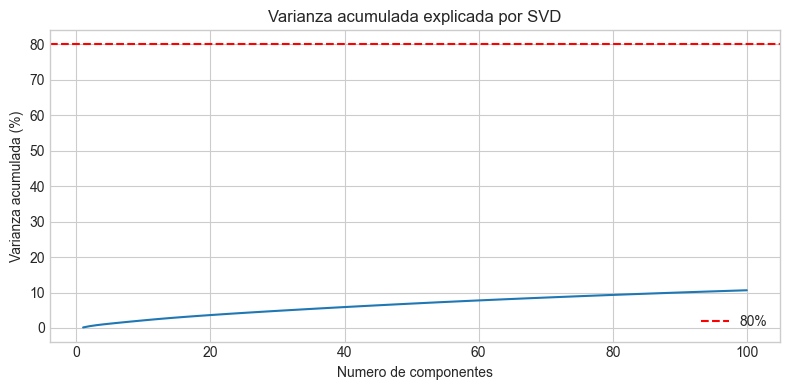

svd_lsa.pkl guardado.


In [21]:
# ==============================================================
# Celda 27 - SVD / LSA (reduccion dimensional)
# ==============================================================

N_COMPONENTS_SVD = 100

print(f'Aplicando SVD con {N_COMPONENTS_SVD} componentes...')
svd = TruncatedSVD(n_components=N_COMPONENTS_SVD, random_state=SEED)
svd.fit(X_tr)

X_tr_svd  = svd.transform(X_tr)
X_vl_svd  = svd.transform(X_vl)
X_te_svd  = svd.transform(X_te)
X_all_svd = np.vstack([X_tr_svd, X_vl_svd, X_te_svd])
y_all_svd = np.concatenate([y_train, y_val, y_test])

var_explicada = svd.explained_variance_ratio_.cumsum()
print(f'Varianza explicada con {N_COMPONENTS_SVD} componentes: {var_explicada[-1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_COMPONENTS_SVD + 1), var_explicada * 100, marker='')
ax.axhline(80, color='red', linestyle='--', label='80%')
ax.set_title('Varianza acumulada explicada por SVD')
ax.set_xlabel('Numero de componentes')
ax.set_ylabel('Varianza acumulada (%)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'svd_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(svd, MODELS_DIR / 'svd_lsa.pkl')
print('svd_lsa.pkl guardado.')

Calculando metricas para K = 2..10...
  K=2: inercia=1048, silueta=0.5570, DB=0.4819
  K=3: inercia=1031, silueta=0.1177, DB=2.8291
  K=4: inercia=1018, silueta=0.0106, DB=4.8173
  K=5: inercia=1006, silueta=0.0083, DB=4.5584
  K=6: inercia=996, silueta=0.0026, DB=4.4472
  K=7: inercia=986, silueta=0.0073, DB=3.9275
  K=8: inercia=972, silueta=0.0054, DB=3.8113
  K=9: inercia=962, silueta=0.0083, DB=3.8453
  K=10: inercia=954, silueta=0.0621, DB=2.5674


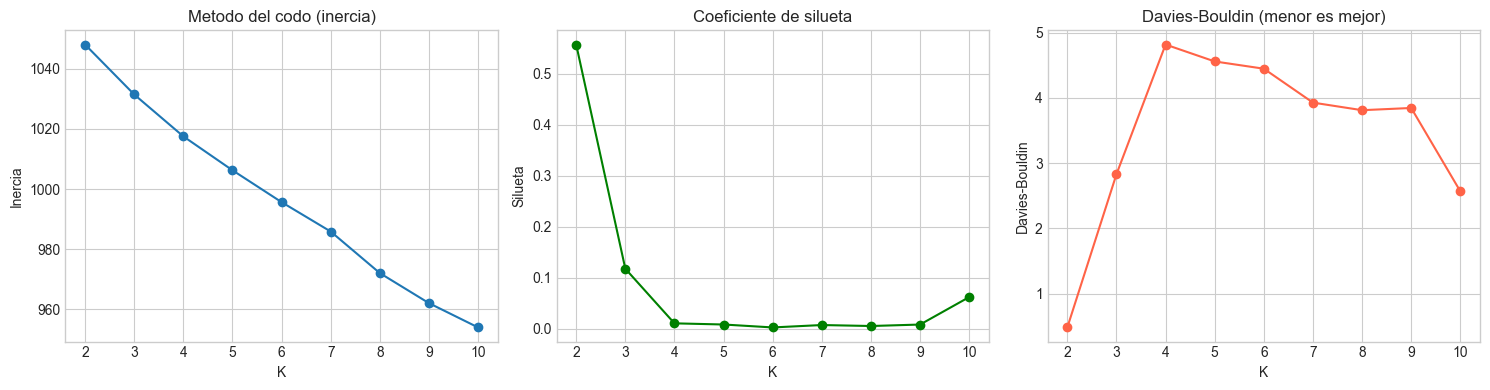

In [22]:
# ==============================================================
# Celda 28 - Seleccion de K (codo + silueta)
# ==============================================================

K_RANGE = range(2, 11)
inercias   = []
siluetas   = []
db_scores  = []

# Usar submuestra para agilizar calculo de silueta
np.random.seed(SEED)
sample_idx = np.random.choice(len(X_all_svd), size=min(10_000, len(X_all_svd)), replace=False)
X_sample   = X_all_svd[sample_idx]

print('Calculando metricas para K = 2..10...')
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_k = km.fit_predict(X_sample)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_sample, labels_k, sample_size=5000, random_state=SEED))
    db_scores.append(davies_bouldin_score(X_sample, labels_k))
    print(f'  K={k}: inercia={km.inertia_:.0f}, silueta={siluetas[-1]:.4f}, DB={db_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_RANGE, inercias, 'o-')
axes[0].set_title('Metodo del codo (inercia)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inercia')

axes[1].plot(K_RANGE, siluetas, 'o-', color='green')
axes[1].set_title('Coeficiente de silueta')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silueta')

axes[2].plot(K_RANGE, db_scores, 'o-', color='tomato')
axes[2].set_title('Davies-Bouldin (menor es mejor)')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Davies-Bouldin')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'clustering_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ==============================================================
# Celda 29 - K-Means final
# ==============================================================

# K optimo: mayor silueta
K_OPT = list(K_RANGE)[int(np.argmax(siluetas))]
print(f'K optimo seleccionado: {K_OPT} (silueta={max(siluetas):.4f})')

kmeans = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=20)
cluster_labels_all = kmeans.fit_predict(X_all_svd)

sil_final = silhouette_score(X_all_svd, cluster_labels_all, sample_size=10_000, random_state=SEED)
db_final  = davies_bouldin_score(X_all_svd, cluster_labels_all)
print(f'Silueta final (K={K_OPT}): {sil_final:.4f}')
print(f'Davies-Bouldin final    : {db_final:.4f}')

joblib.dump(kmeans, MODELS_DIR / 'kmeans.pkl')
print('kmeans.pkl guardado.')

K optimo seleccionado: 2 (silueta=0.5570)
Silueta final (K=2): 0.5601
Davies-Bouldin final    : 0.4856
kmeans.pkl guardado.


Top 10 terminos por cluster:
  Cluster 0: ['good product', 'product', 'good', 'well', 'great quality', 'wanted', 'nice product', 'product good', 'works great', 'quality product']
  Cluster 1: ['like', 'great', 'one', 'use', 'would', 'good', 'nice', 'well', 'love', 'get']


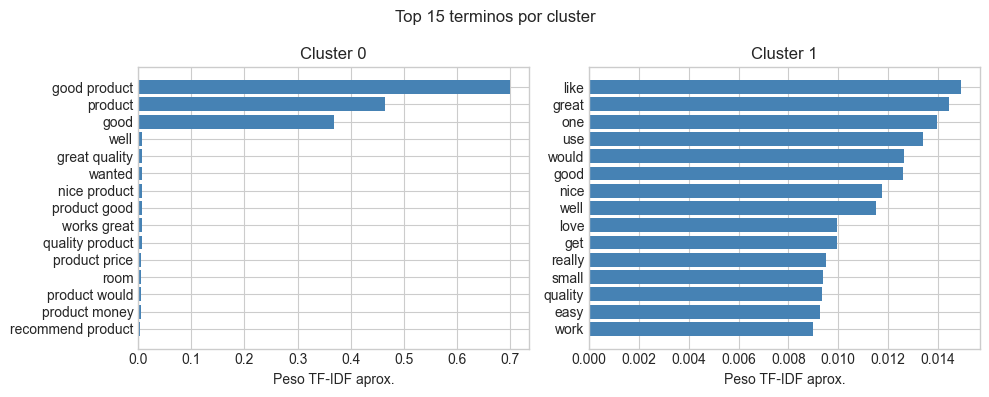

In [24]:
# ==============================================================
# Celda 30 - Terminos mas representativos por cluster
# ==============================================================

feature_names = np.array(tfidf.get_feature_names_out())

# Centros SVD -> espacio TF-IDF aprox. (inversa SVD)
centers_tfidf = svd.inverse_transform(kmeans.cluster_centers_)

print('Top 10 terminos por cluster:')
top_terms_cluster = {}
for k in range(K_OPT):
    top_idx = centers_tfidf[k].argsort()[::-1][:10]
    top_terms = feature_names[top_idx].tolist()
    top_terms_cluster[k] = top_terms
    print(f'  Cluster {k}: {top_terms}')

fig, axes = plt.subplots(1, K_OPT, figsize=(5 * K_OPT, 4))
if K_OPT == 1:
    axes = [axes]

for k, ax in enumerate(axes):
    scores = centers_tfidf[k][centers_tfidf[k].argsort()[::-1][:15]]
    terms  = feature_names[centers_tfidf[k].argsort()[::-1][:15]]
    ax.barh(list(reversed(terms)), list(reversed(scores)), color='steelblue')
    ax.set_title(f'Cluster {k}')
    ax.set_xlabel('Peso TF-IDF aprox.')

plt.suptitle('Top 15 terminos por cluster', fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'clustering_terminos.png', dpi=150, bbox_inches='tight')
plt.show()

Reduciendo a 2D con PCA para visualizacion...


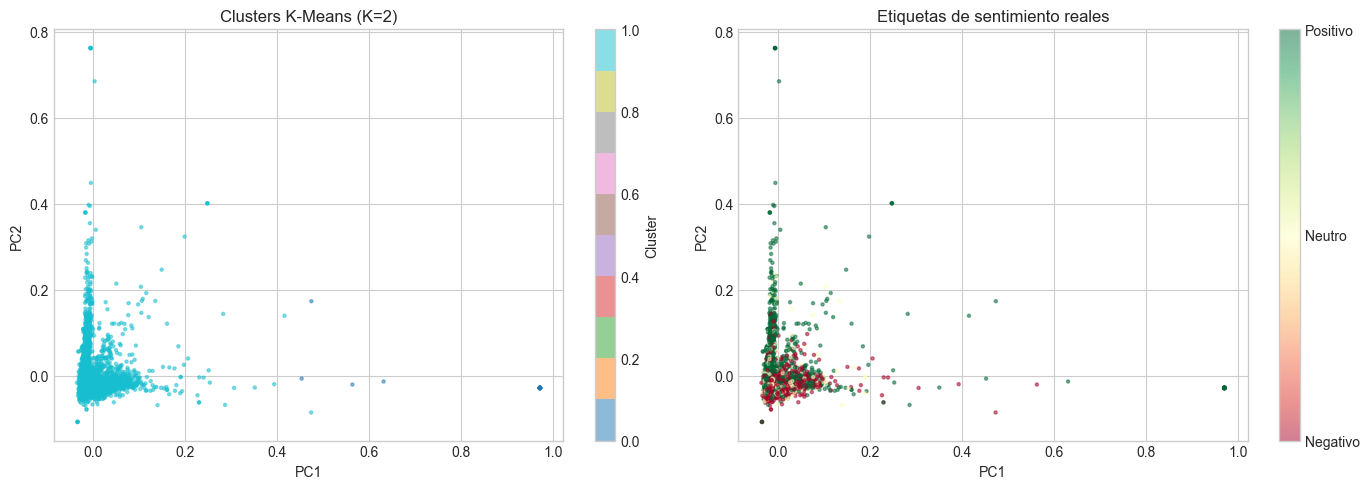

In [25]:
# ==============================================================
# Celda 31 - Visualizacion 2D con PCA
# ==============================================================

print('Reduciendo a 2D con PCA para visualizacion...')
np.random.seed(SEED)
vis_idx   = np.random.choice(len(X_all_svd), size=5000, replace=False)
X_vis     = X_all_svd[vis_idx]
clust_vis = cluster_labels_all[vis_idx]
label_vis = y_all_svd[vis_idx]

pca2 = PCA(n_components=2, random_state=SEED)
X_2d = pca2.fit_transform(X_vis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=clust_vis, cmap='tab10', s=5, alpha=0.5
)
axes[0].set_title(f'Clusters K-Means (K={K_OPT})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=label_vis, cmap='RdYlGn', s=5, alpha=0.5,
    vmin=0, vmax=2
)
axes[1].set_title('Etiquetas de sentimiento reales')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
cbar = plt.colorbar(scatter2, ax=axes[1], ticks=[0, 1, 2])
cbar.set_ticklabels(['Negativo', 'Neutro', 'Positivo'])

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'clustering_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

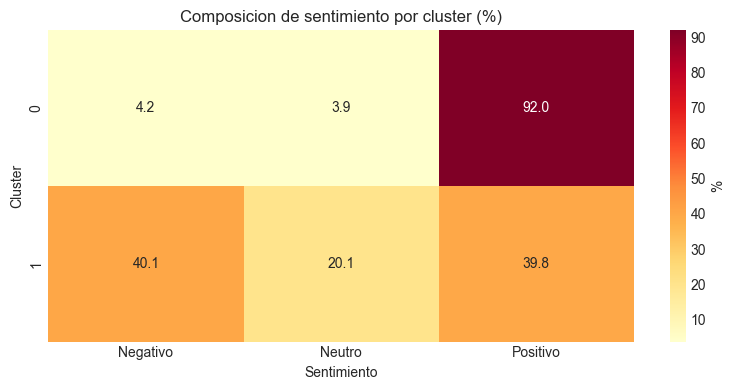

Composicion de sentimiento por cluster (%):


sentimien,Negativo,Neutro,Positivo
cluster,,,
0,4.2,3.9,92.0
1,40.1,20.1,39.8


In [26]:
# ==============================================================
# Celda 32 - Cluster vs sentimiento (heatmap de contingencia)
# ==============================================================

df_cluster = pd.DataFrame({
    'cluster'  : cluster_labels_all,
    'sentimien': [CLASS_NAMES[l] for l in y_all_svd]
})

contingencia = pd.crosstab(
    df_cluster['cluster'],
    df_cluster['sentimien'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    contingencia,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': '%'}
)
ax.set_title('Composicion de sentimiento por cluster (%)')
ax.set_xlabel('Sentimiento')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'clustering_vs_sentimiento.png', dpi=150, bbox_inches='tight')
plt.show()

print('Composicion de sentimiento por cluster (%):')
display(contingencia.round(1))

---
## Seccion 7 — Guardado de Artefactos

Se persisten todos los artefactos del pipeline en `models/`:
- `tfidf.pkl` — vectorizador TF-IDF estandar
- `svd_lsa.pkl` — reductor dimensional SVD
- `kmeans.pkl` — modelo de clustering
- `lr_model.pkl` — Logistic Regression
- `rf_model.pkl` — Random Forest
- `lgbm_model.pkl` — LightGBM
- `flaml_automl.pkl` — FLAML AutoML

Se incluye una celda de demostracion de inferencia end-to-end.

In [27]:
# ==============================================================
# Celda 34 - Guardar artefactos
# ==============================================================

artefactos = {
    'tfidf.pkl'      : tfidf,
    'svd_lsa.pkl'    : svd,
    'kmeans.pkl'     : kmeans,
    'lr_model.pkl'   : lr_model,
    'rf_model.pkl'   : rf_model,
    'lgbm_model.pkl' : lgbm_model,
    'flaml_automl.pkl': flaml_model,
}

for nombre_archivo, obj in artefactos.items():
    ruta = MODELS_DIR / nombre_archivo
    joblib.dump(obj, ruta)
    size_kb = ruta.stat().st_size / 1024
    print(f'  Guardado: {nombre_archivo} ({size_kb:.1f} KB)')

print('\nTodos los artefactos guardados en models/')

  Guardado: tfidf.pkl (1972.6 KB)
  Guardado: svd_lsa.pkl (39065.6 KB)
  Guardado: kmeans.pkl (392.9 KB)
  Guardado: lr_model.pkl (1172.7 KB)
  Guardado: rf_model.pkl (235130.1 KB)
  Guardado: lgbm_model.pkl (11798.2 KB)
  Guardado: flaml_automl.pkl (14417.8 KB)

Todos los artefactos guardados en models/


In [28]:
# ==============================================================
# Celda 35 - Demo de inferencia end-to-end
# ==============================================================

def predecir_sentimiento(texto_nuevo, modelo_clf=None, vectorizador=None):
    if modelo_clf is None:
        modelo_clf = joblib.load(MODELS_DIR / 'lgbm_model.pkl')
    if vectorizador is None:
        vectorizador = joblib.load(MODELS_DIR / 'tfidf.pkl')

    texto_limpio = clean_text(texto_nuevo)
    X_nuevo = vectorizador.transform([texto_limpio])
    pred    = modelo_clf.predict(X_nuevo)[0]
    proba   = modelo_clf.predict_proba(X_nuevo)[0]

    return {
        'texto_original': texto_nuevo,
        'sentimiento'   : CLASS_NAMES[pred],
        'probabilidades': {
            CLASS_NAMES[i]: round(float(p), 4)
            for i, p in enumerate(proba)
        }
    }


ejemplos = [
    'This product is absolutely amazing, works perfectly and arrived on time!',
    'It broke after two days. Complete waste of money, very disappointed.',
    'It is okay, nothing special. Does what it says but not impressive.',
]

print('Demo de inferencia (LightGBM):')
for texto in ejemplos:
    resultado = predecir_sentimiento(texto, lgbm_model, tfidf)
    print(f"\n  Texto      : {resultado['texto_original'][:80]}")
    print(f"  Sentimiento: {resultado['sentimiento']}")
    print(f"  Probs      : {resultado['probabilidades']}")

Demo de inferencia (LightGBM):

  Texto      : This product is absolutely amazing, works perfectly and arrived on time!
  Sentimiento: Positivo
  Probs      : {'Negativo': 0.0208, 'Neutro': 0.0032, 'Positivo': 0.9761}

  Texto      : It broke after two days. Complete waste of money, very disappointed.
  Sentimiento: Negativo
  Probs      : {'Negativo': 0.9899, 'Neutro': 0.0084, 'Positivo': 0.0016}

  Texto      : It is okay, nothing special. Does what it says but not impressive.
  Sentimiento: Neutro
  Probs      : {'Negativo': 0.2267, 'Neutro': 0.6862, 'Positivo': 0.0871}


---
## Seccion 8 — Conclusiones

### 8.1 Modelos de clasificacion

Los cuatro modelos entrenados demuestran que la clasificacion de sentimiento sobre reseñas de Amazon
es un problema bien estructurado cuando se aplica TF-IDF con bigramas y sublinear TF.

| Modelo | Accuracy | F1-macro | ROC-AUC |
|---|---|---|---|
| Logistic Regression | 0.7192 | **0.6307** | **0.8509** |
| LightGBM | 0.7089 | 0.6289 | 0.8456 |
| FLAML AutoML | 0.6905 | 0.6125 | 0.8309 |
| Random Forest | 0.6865 | 0.5199 | 0.8302 |

- **Logistic Regression** resulto ser el mejor modelo en el conjunto de prueba, alcanzando
  F1-macro = 0.6307 y ROC-AUC = 0.8509. Su ventaja frente a LightGBM se explica por la
  representacion TF-IDF de alta dimensionalidad (50k features): en espacios esparsos y linealmente
  separables, los modelos lineales regularizados son altamente competitivos.
- **LightGBM** quedo en segundo lugar con F1-macro = 0.6289, diferencia marginal respecto a LR.
  Su capacidad de capturar interacciones no lineales no genera una mejora significativa sobre la
  representacion TF-IDF, aunque su rendimiento es solido.
- **FLAML AutoML** selecciono automaticamente `lgbm` como mejor estimador dentro del presupuesto
  de 120 segundos, operando con TF-IDF compacto (10k features). A pesar de contar con menos
  informacion textual, logro un F1-macro competitivo (0.6125).
- **Random Forest** fue el modelo de menor desempeno (F1-macro = 0.5199), con una caida notable
  en la clase Neutro (recall ~2%). Los arboles de decision son menos eficientes en espacios de
  alta dimensionalidad y dispersos como TF-IDF.

La clase **Neutro (3 estrellas)** es la mas dificil de clasificar en todos los modelos,
dado que el lenguaje ambiguo de las reseñas de 3 estrellas comparte vocabulario tanto
con reseñas positivas como negativas.

### 8.2 Clustering K-Means

El analisis de codo y el coeficiente de silueta determinaron **K = 2** como el numero optimo
de clusters (silueta = 0.5601, Davies-Bouldin = 0.4856), lo que indica una separacion clara
y compacta entre los dos grupos.

El analisis de los terminos mas representativos por cluster revela dos patrones linguisticos
diferenciados:

- **Cluster 0** (`good product`, `great quality`, `works great`, `recommend product`,
  `product price`): dominado por lenguaje evaluativo explicito del producto. Agrupa reseñas
  que describen directamente la calidad, el valor y la recomendacion del articulo.
- **Cluster 1** (`like`, `great`, `one`, `use`, `would`, `love`, `easy`, `nice`):
  dominado por adjetivos y verbos de experiencia general. Agrupa reseñas con lenguaje mas
  subjetivo y orientado al uso personal.

Esta separacion no coincide exactamente con el eje positivo/negativo del sentimiento, sino
que refleja dos estilos de escritura: evaluacion objetiva del producto vs. experiencia
personal del usuario. El solapamiento residual es esperable en un corpus generalista como
Home and Kitchen, que abarca cientos de categorias de productos.

### 8.3 Limitaciones y trabajo futuro

- El submuestreo de 20 000 reseñas por clase balancea artificialmente el dataset;
  en produccion la clase **Positivo** dominaria (~70% de las reseñas de Amazon).
- TF-IDF no captura contexto semantico; representaciones vectoriales como
  `sentence-transformers` o modelos BERT fine-tuneados podrian mejorar sustancialmente
  la clasificacion de la clase Neutro.
- El clustering se beneficiaria de tecnicas de reduccion dimensional mas modernas
  (UMAP + HDBSCAN) para identificar clusters de forma mas natural y menos sensibles
  a la geometria euclidiana en espacios de alta dimension.
- Las fases siguientes del proyecto (Fase 3-5) podrian incorporar redes neuronales
  recurrentes o transformers para capturar dependencias de largo alcance en el texto.